# Proyecto Final IA — Análisis Comparativo con Escenarios

Este notebook integra el proyecto completo y agrega un **análisis por escenarios del hospital**. La idea no es forzar que Q-Learning supere a Value Iteration, sino demostrar cómo cambia el desempeño de ambos enfoques cuando el hospital se vuelve más congestionado, riesgoso o mixto.

**Comparación principal:**

- **Value Iteration:** método basado en modelo. Conoce las transiciones del MDP y calcula una política con la ecuación de Bellman.
- **Q-Learning:** método model-free. Aprende por experiencia mediante episodios, sin conocer directamente las probabilidades de transición.

**Métricas evaluadas:**

- Tiempo promedio de entrega.
- Consumo promedio de batería.
- Porcentaje de entregas exitosas.
- Recompensa acumulada promedio.
- Fallos de misión.

## 1. Configuración inicial

Esta sección importa librerías, configura rutas del repositorio y crea las carpetas donde se guardarán tablas y gráficas.

In [10]:
from pathlib import Path
import sys
import random
import subprocess
import copy

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def find_project_root(start=None):
    """
    Busca automáticamente la raíz del repositorio.
    La raíz debe contener las carpetas src/ y tests/.
    """
    start = Path(start or Path.cwd()).resolve()

    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "tests").exists():
            return path

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "Asegúrate de abrir el notebook dentro del repositorio IA_Proyecto_Final."
    )


# Detectar raíz del proyecto
ROOT = find_project_root()

# Agregar raíz al path para poder importar src.environment, src.q_learning, etc.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Carpetas de salida
RESULTS_DIR = ROOT / "results"
plots_dir = RESULTS_DIR / "plots"
tables_dir = RESULTS_DIR / "tables"

plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Semilla base para resultados más comparables
random.seed(42)

print("Raíz del proyecto:", ROOT)
print("Carpeta de gráficas:", plots_dir.relative_to(ROOT))
print("Carpeta de tablas:", tables_dir.relative_to(ROOT))

Raíz del proyecto: /home/ricgo/2026_S1/IA/IA_Proyecto_Final
Carpeta de gráficas: results/plots
Carpeta de tablas: results/tables


## 2. Validación con pruebas automatizadas

Antes de generar resultados, se ejecutan las pruebas unitarias. Esto ayuda a confirmar que el entorno y Q-Learning siguen funcionando después de cambios en el proyecto.

In [11]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-v"],
    cwd=ROOT,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)


/home/ricgo/2026_S1/IA/IA_Proyecto_Final/venv/bin/python: No module named pytest



## 3. Importar módulos del proyecto

Se importan los archivos principales del repositorio:

- `environment.py`: define el hospital, acciones, batería, recompensas y transición estocástica.
- `value_iteration.py`: calcula la política óptima con Bellman.
- `q_learning.py`: entrena un agente mediante experiencia.
- `metrics.py`: evalúa y compara agentes.

In [12]:
from src.environment import (
    HospitalEnvironment,
    Action,
    HOSPITAL_MAP,
    START_POS,
    GOAL_POS,
    CHARGE_POS,
    MAX_BATTERY,
    W, P, S, G, C, R, Z,
)
from src.metrics import evaluate_agent, compare_agents, save_results_table
from src.scenarios import SCENARIO_CHANGES, SCENARIO_NAMES, create_env_for_scenario
from src.experiments import (
    train_value_iteration,
    train_q_learning,
    evaluate_model,
    Q_LEARNING_CONFIGS,
    run_q_experiment,
    pick_best_q_config,
)

## 4. Revisión rápida del entorno base

Esta celda confirma que el robot inicia correctamente, cuál es el destino, cuál es la batería máxima y qué acciones puede tomar al inicio.

In [13]:
env = HospitalEnvironment()
initial_state = env.reset()

print("Estado inicial:", initial_state)
print("Posición inicial esperada:", START_POS)
print("Destino:", GOAL_POS)
print("Estación de carga:", CHARGE_POS)
print("Batería máxima:", MAX_BATTERY)
print("Acciones posibles al inicio:", [a.name for a in env.get_possible_actions(initial_state)])

Estado inicial: (1, 1, 30)
Posición inicial esperada: (1, 1)
Destino: (10, 14)
Estación de carga: (5, 5)
Batería máxima: 30
Acciones posibles al inicio: ['UP', 'DOWN', 'LEFT', 'RIGHT', 'STAY']


## 5. Visualización del mapa del hospital

Se crea una función para dibujar el hospital. Los colores ayudan a identificar paredes, pasillos, zonas congestionadas, zonas de riesgo, estación de carga, inicio y destino.

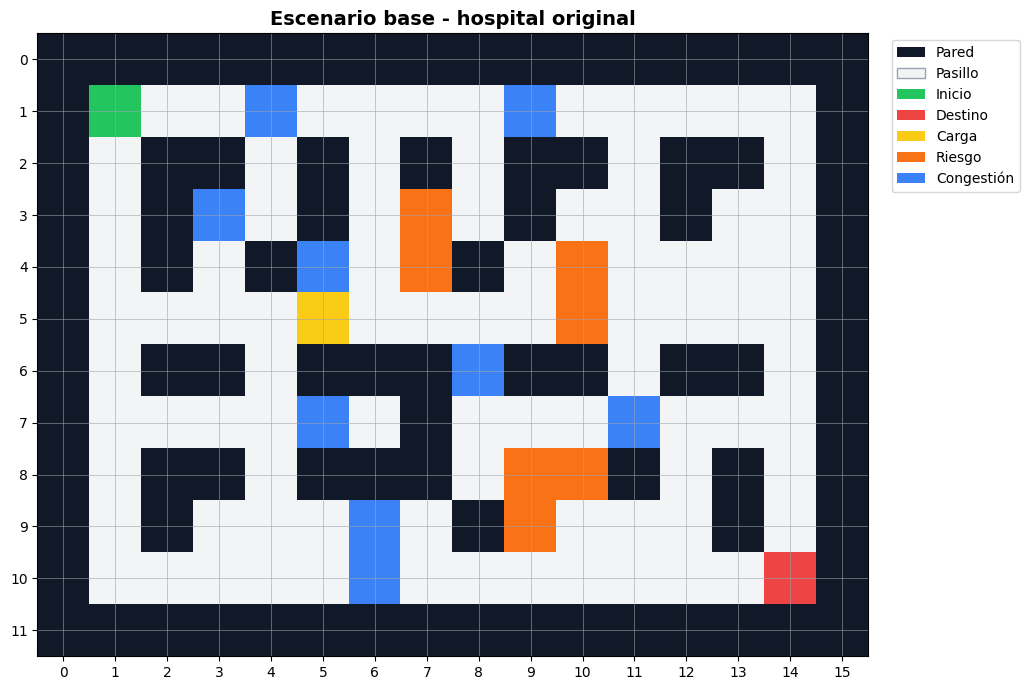

In [14]:
cell_to_number = {
    W: 0,  # pared
    P: 1,  # pasillo
    S: 2,  # inicio
    G: 3,  # destino
    C: 4,  # carga
    R: 5,  # riesgo
    Z: 6,  # congestión
}

cell_colors = [
    "#111827",  # pared
    "#f3f4f6",  # pasillo
    "#22c55e",  # inicio
    "#ef4444",  # destino
    "#facc15",  # carga
    "#f97316",  # riesgo
    "#3b82f6",  # congestión
]

legend_items = [
    Patch(facecolor="#111827", label="Pared"),
    Patch(facecolor="#f3f4f6", edgecolor="#9ca3af", label="Pasillo"),
    Patch(facecolor="#22c55e", label="Inicio"),
    Patch(facecolor="#ef4444", label="Destino"),
    Patch(facecolor="#facc15", label="Carga"),
    Patch(facecolor="#f97316", label="Riesgo"),
    Patch(facecolor="#3b82f6", label="Congestión"),
]


def map_to_matrix(hospital_map):
    return [[cell_to_number[cell] for cell in row] for row in hospital_map]


def plot_hospital_map(env, title="Mapa del hospital", filename=None):
    matrix = map_to_matrix(env.map)
    cmap = ListedColormap(cell_colors)

    plt.figure(figsize=(11, 7))
    plt.imshow(matrix, cmap=cmap, vmin=0, vmax=6)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.grid(which="both", color="#9ca3af", linewidth=0.4)
    plt.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if filename:
        plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)

    plt.show()


plot_hospital_map(env, "Escenario base - hospital original", "mapa_base.png")

## 6. Funciones auxiliares para escenarios

En lugar de modificar permanentemente `environment.py`, se crean escenarios dentro del notebook. Todos mantienen el mismo inicio, destino y estación de carga para que la comparación sea justa.

Escenarios propuestos:

1. **Base:** hospital original.
2. **Congestionado:** más celdas `Z`, simulando pasillos con más tráfico.
3. **Riesgo alto:** más celdas `R`, simulando zonas críticas o restringidas.
4. **Mixto:** combina congestión y riesgo para representar un hospital más complejo.

## 7. Visualización de escenarios

Estos mapas permiten explicar mejor el análisis. No se cambia la lógica de los algoritmos; solo se evalúa cómo responden ante diferentes condiciones del hospital.

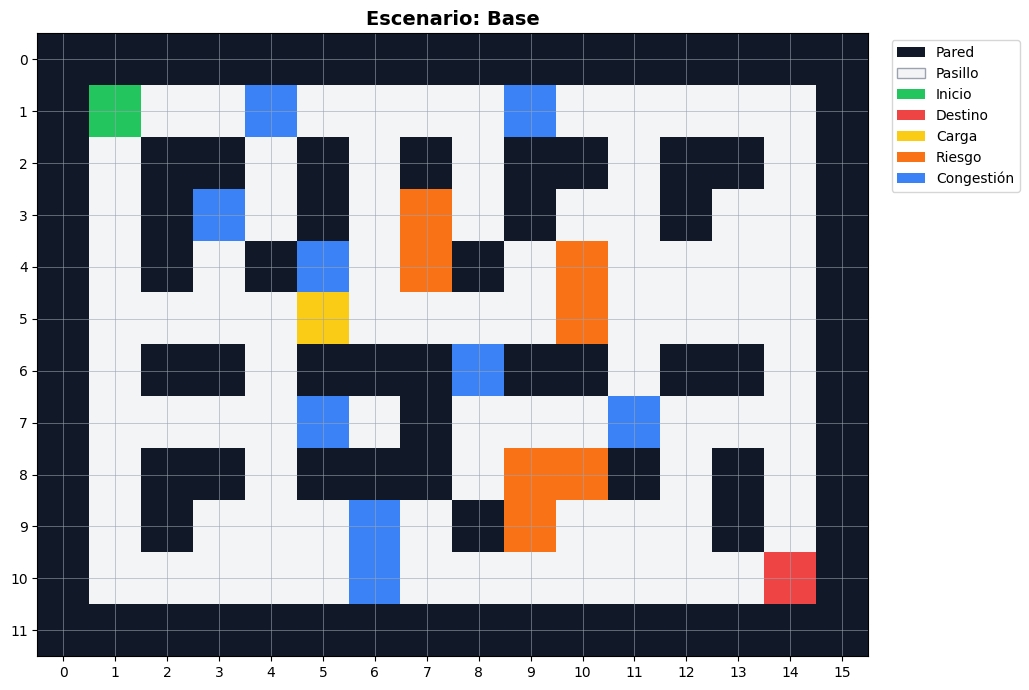

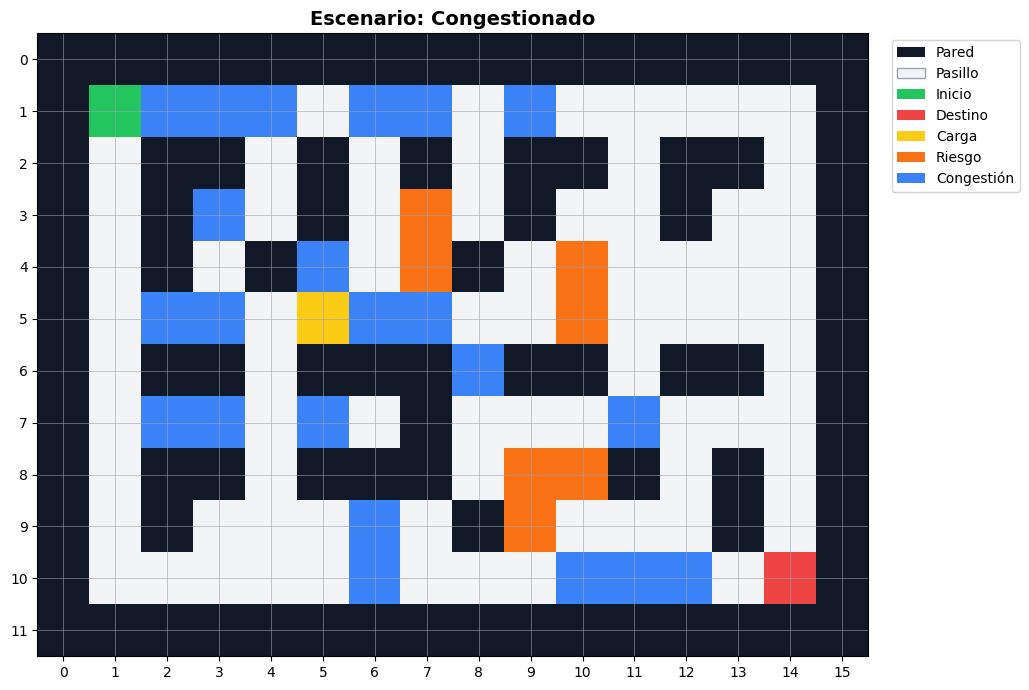

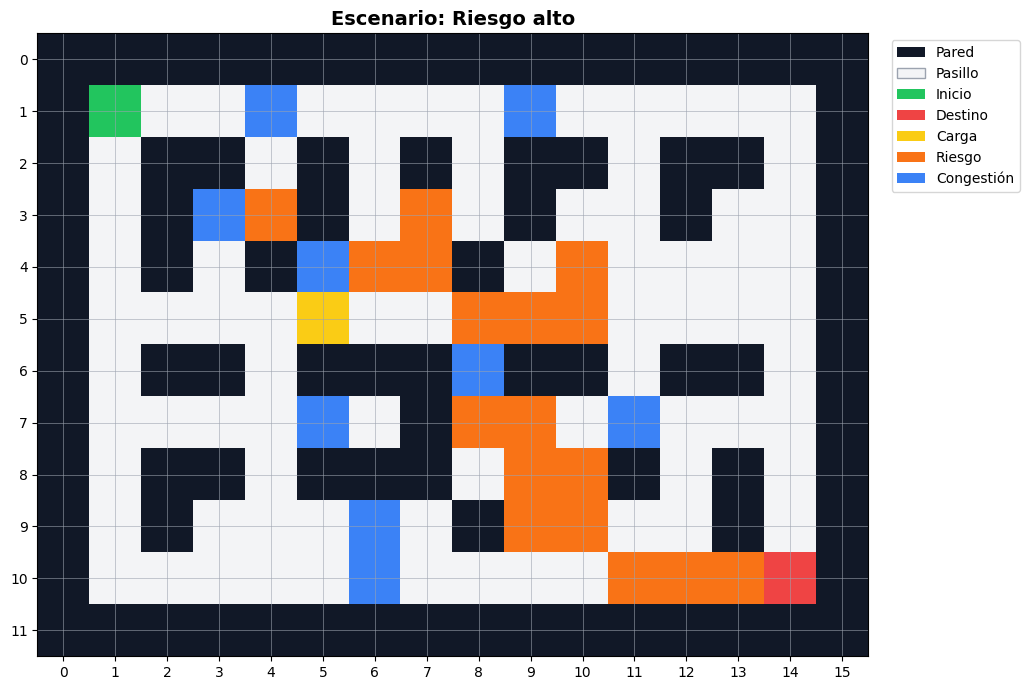

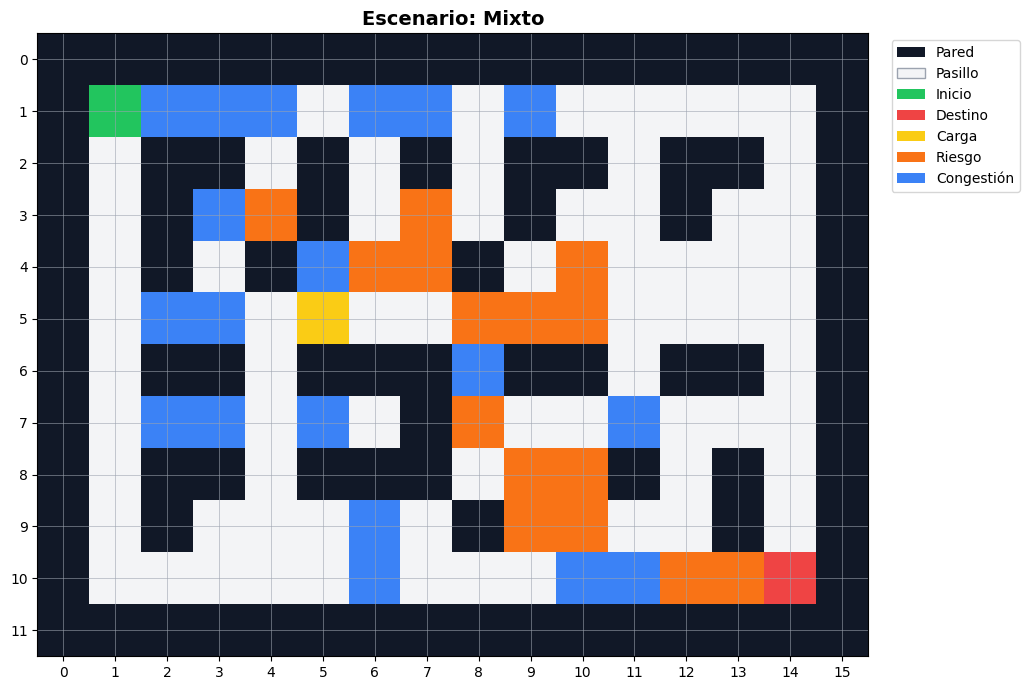

In [15]:
for scenario_name in SCENARIO_CHANGES.keys():
    scenario_env = create_env_for_scenario(scenario_name)
    filename = f"mapa_{scenario_name.lower().replace(' ', '_')}.png"
    plot_hospital_map(scenario_env, f"Escenario: {scenario_name}", filename)

## 8. Funciones para entrenar y evaluar agentes

Estas funciones permiten correr Value Iteration y Q-Learning de forma ordenada. También se guarda información por episodio para analizar aprendizaje y resultados.

## 9. Experimentos de Q-Learning en el escenario base

Primero se prueban varias configuraciones de Q-Learning en el escenario base. Esto permite observar si el agente mejora cuando se ajustan episodios, `gamma` o `epsilon`.

**Nota teórica:** no se espera que Q-Learning supere de forma estable a Value Iteration en este caso, porque Value Iteration conoce el modelo del entorno. Lo interesante es ver cuánto se acerca Q-Learning al aprender por experiencia.

In [16]:
EVAL_EPISODES = 100
EVAL_MAX_STEPS = 200

q_experiment_results = []
q_agents = {}

for config in Q_LEARNING_CONFIGS:
    print("Entrenando:", config["name"])
    env_q = create_env_for_scenario("Base")
    agent_q = run_q_experiment(config, env_q)

    result_q = evaluate_model(
        env_q,
        agent_q,
        name=config["name"],
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
    )

    result_q["config"] = config
    q_experiment_results.append(result_q)
    q_agents[config["name"]] = agent_q

q_experiment_table = compare_agents(*q_experiment_results)
q_experiment_table["Tiempo promedio de entrega"] = q_experiment_table["Tiempo promedio de entrega"].round(2)
q_experiment_table["Consumo promedio de batería"] = q_experiment_table["Consumo promedio de batería"].round(2)
q_experiment_table["% entregas exitosas"] = q_experiment_table["% entregas exitosas"].round(1)
q_experiment_table["Recompensa acumulada promedio"] = q_experiment_table["Recompensa acumulada promedio"].round(2)

q_experiment_table

Entrenando: Q-Learning base
Entrenando: Q-Learning más episodios
Entrenando: Q-Learning gamma alto
Entrenando: Q-Learning más explotación
Entrenando: Q-Learning epsilon decay


,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Q-Learning base,100,30.98,29.55,66.0,11.16,34
1,Q-Learning más episodios,100,31.75,29.19,67.0,11.35,33
2,Q-Learning gamma alto,100,32.45,28.65,77.0,25.17,23
3,Q-Learning más explotación,100,34.10,29.03,73.0,18.04,27
4,Q-Learning epsilon decay,100,30.18,29.13,66.0,10.67,34


## 10. Elegir la mejor configuración de Q-Learning

Se selecciona automáticamente la mejor configuración de Q-Learning usando como prioridad:

1. Mayor porcentaje de entregas exitosas.
2. Mayor recompensa acumulada promedio.
3. Menor cantidad de fallos.

In [17]:
best_q_config = pick_best_q_config(q_experiment_results, Q_LEARNING_CONFIGS)
best_q_name = best_q_config["name"]

print("Mejor configuración Q-Learning:", best_q_name)
print(best_q_config)

Mejor configuración Q-Learning: Q-Learning gamma alto
{'name': 'Q-Learning gamma alto', 'type': 'standard', 'episodes': 80000, 'alpha': 0.1, 'gamma': 0.98, 'epsilon': 0.3, 'seed': 45}


## 11. Curva de aprendizaje de la mejor configuración Q-Learning

Esta gráfica es importante porque muestra que Q-Learning aprende mediante experiencia. La línea suave representa un promedio móvil para observar la tendencia general.

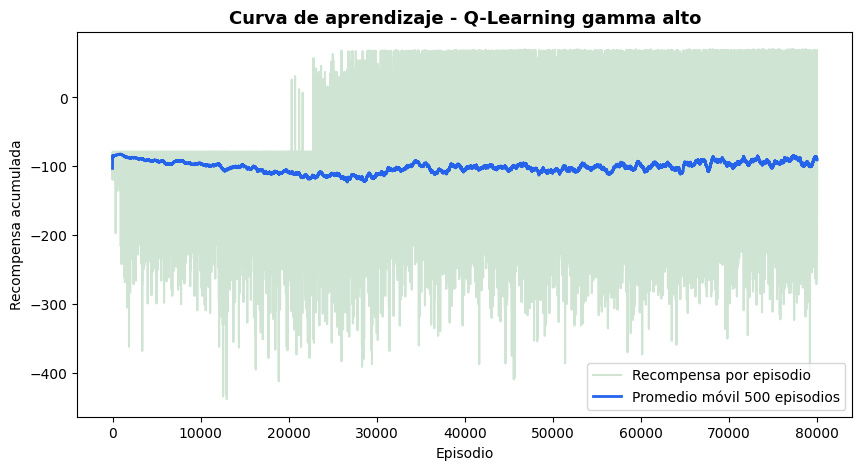

In [18]:
best_q_agent = q_agents[best_q_name]

rewards = pd.Series(best_q_agent.rewards_per_episode)
rolling_rewards = rewards.rolling(window=500, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.20, color="#0f7826", label="Recompensa por episodio")
plt.plot(rolling_rewards, color="#2563eb", linewidth=2, label="Promedio móvil 500 episodios")
plt.title(f"Curva de aprendizaje - {best_q_name}", fontsize=13, fontweight="bold")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.legend()
plt.savefig(plots_dir / "q_learning_mejor_curva_aprendizaje.png", bbox_inches="tight", dpi=150)
plt.show()

## 12. Comparación principal en escenario base

Ahora se compara Value Iteration contra la mejor configuración encontrada de Q-Learning en el escenario base.

In [19]:
env_vi_base = create_env_for_scenario("Base")
vi_agent_base = train_value_iteration(env_vi_base, gamma=0.9, theta=1e-3, verbose=True)

result_vi_base = evaluate_model(
    env_vi_base,
    vi_agent_base,
    name="Value Iteration",
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
)

# Reentrenar mejor Q-Learning para comparación limpia
env_q_base = create_env_for_scenario("Base")
best_q_agent_base = run_q_experiment(best_q_config, env_q_base)

result_q_base = evaluate_model(
    env_q_base,
    best_q_agent_base,
    name=best_q_name,
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
)

base_comparison = compare_agents(result_vi_base, result_q_base)
base_comparison["Tiempo promedio de entrega"] = base_comparison["Tiempo promedio de entrega"].round(2)
base_comparison["Consumo promedio de batería"] = base_comparison["Consumo promedio de batería"].round(2)
base_comparison["% entregas exitosas"] = base_comparison["% entregas exitosas"].round(1)
base_comparison["Recompensa acumulada promedio"] = base_comparison["Recompensa acumulada promedio"].round(2)

save_results_table(base_comparison, tables_dir / "metricas_base_vi_vs_mejor_q_learning.csv")
base_comparison

Iter   10  Δ = 19.371024
Iter   20  Δ = 2.927521
Iter   30  Δ = 0.306108
Iter   40  Δ = 0.083290
Iter   50  Δ = 0.001963
Convergió en 52 iteraciones (Δ = 0.000942)


,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Value Iteration,100,28.98,26.00,90.0,48.60,10
1,Q-Learning gamma alto,100,32.45,28.65,77.0,25.17,23


## 13. Gráficas comparativas del escenario base

Se generan gráficas con colores consistentes para comparar ambos agentes.

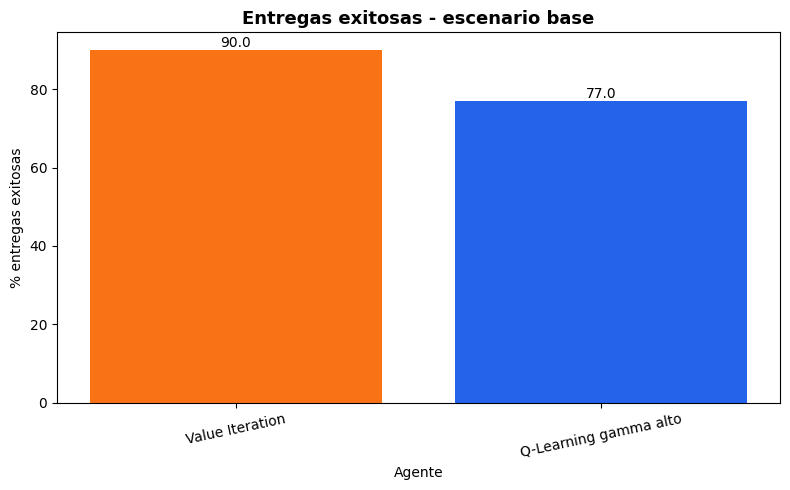

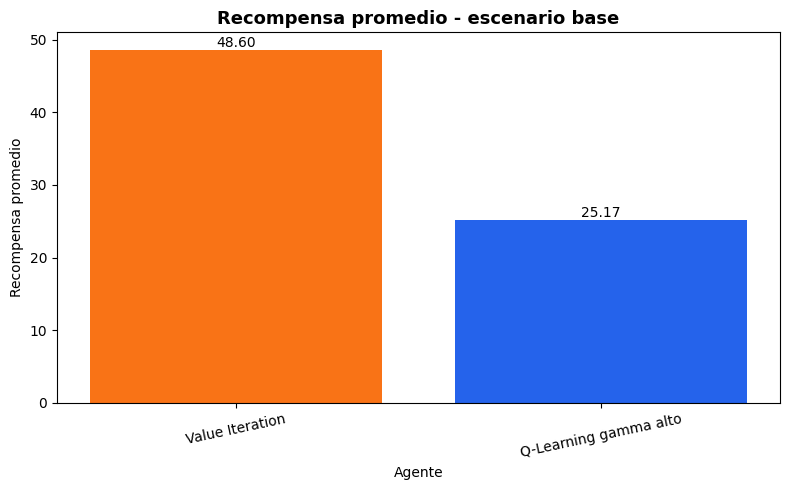

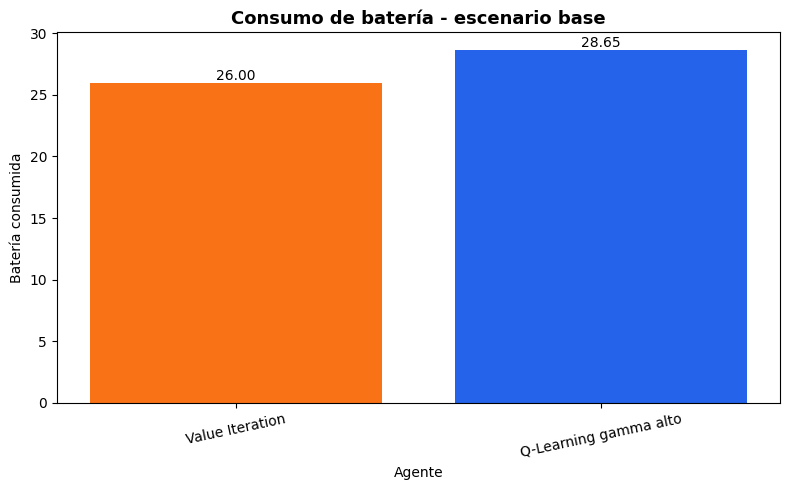

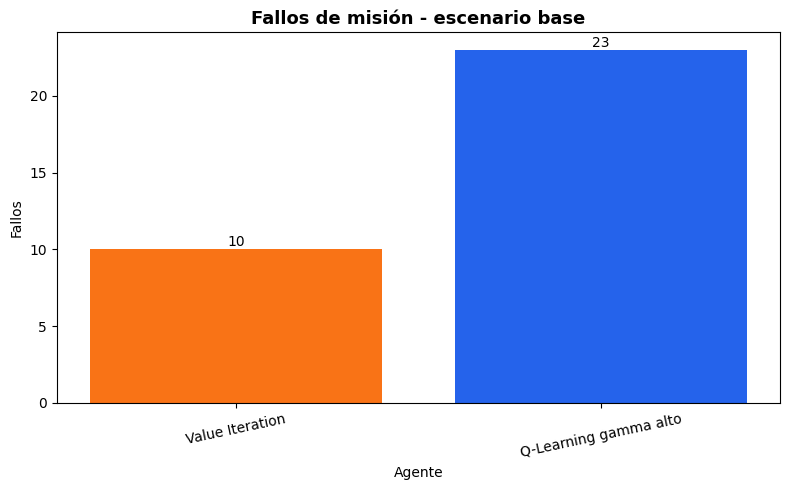

In [20]:
agent_colors = {
    "Value Iteration": "#f97316",
    best_q_name: "#2563eb",
    "Q-Learning base": "#60a5fa",
    "Q-Learning más episodios": "#3b82f6",
    "Q-Learning gamma alto": "#2563eb",
    "Q-Learning más explotación": "#1d4ed8",
}


def save_bar_chart(df, column, title, ylabel, filename, decimals=2):
    data = df.copy()
    original_values = data[column]
    plot_values = original_values.fillna(0)
    colors = [agent_colors.get(agent, "#6b7280") for agent in data["Agente"]]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(data["Agente"], plot_values, color=colors)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.ylabel(ylabel)
    plt.xlabel("Agente")
    plt.xticks(rotation=12)

    for bar, value in zip(bars, original_values):
        if pd.notna(value):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.{decimals}f}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout()
    plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)
    plt.show()


save_bar_chart(
    base_comparison,
    "% entregas exitosas",
    "Entregas exitosas - escenario base",
    "% entregas exitosas",
    "base_entregas_exitosas.png",
    decimals=1,
)

save_bar_chart(
    base_comparison,
    "Recompensa acumulada promedio",
    "Recompensa promedio - escenario base",
    "Recompensa promedio",
    "base_recompensa_promedio.png",
    decimals=2,
)

save_bar_chart(
    base_comparison,
    "Consumo promedio de batería",
    "Consumo de batería - escenario base",
    "Batería consumida",
    "base_consumo_bateria.png",
    decimals=2,
)

save_bar_chart(
    base_comparison,
    "Fallos de misión",
    "Fallos de misión - escenario base",
    "Fallos",
    "base_fallos_mision.png",
    decimals=0,
)

## 14. Análisis por escenarios del hospital

En esta sección se evalúa la robustez de los algoritmos. Se usa la mejor configuración de Q-Learning encontrada en el escenario base y se compara contra Value Iteration en varios mapas.

Esto permite responder una pregunta más fuerte para el proyecto:

> ¿Qué tan estable es cada enfoque cuando cambian las condiciones del hospital?

In [21]:
scenario_results = []

for scenario_name in SCENARIO_NAMES[1:]:  # omite Base — comparado en comparacion_base.ipynb
    print("Evaluando escenario:", scenario_name)

    # Value Iteration
    env_vi = create_env_for_scenario(scenario_name)
    vi_agent = train_value_iteration(env_vi, gamma=0.9, theta=1e-3, verbose=False)
    vi_result = evaluate_model(
        env_vi,
        vi_agent,
        name="Value Iteration",
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
    )
    vi_result["scenario"] = scenario_name
    scenario_results.append(vi_result)

    # Q-Learning con la mejor configuración encontrada
    env_q = create_env_for_scenario(scenario_name)
    q_agent = run_q_experiment(best_q_config, env_q)
    q_result = evaluate_model(
        env_q,
        q_agent,
        name=best_q_name,
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
    )
    q_result["scenario"] = scenario_name
    scenario_results.append(q_result)

scenario_rows = []
for result in scenario_results:
    scenario_rows.append({
        "Escenario": result["scenario"],
        "Agente": result["agent"],
        "Episodios evaluación": result["episodes"],
        "Tiempo promedio de entrega": result["avg_delivery_time"],
        "Consumo promedio de batería": result["avg_battery_consumption"],
        "% entregas exitosas": result["success_rate"],
        "Recompensa acumulada promedio": result["avg_reward"],
        "Fallos de misión": result["mission_failures"],
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_table["Tiempo promedio de entrega"] = scenario_table["Tiempo promedio de entrega"].round(2)
scenario_table["Consumo promedio de batería"] = scenario_table["Consumo promedio de batería"].round(2)
scenario_table["% entregas exitosas"] = scenario_table["% entregas exitosas"].round(1)
scenario_table["Recompensa acumulada promedio"] = scenario_table["Recompensa acumulada promedio"].round(2)

scenario_table.to_csv(
    tables_dir / "comparacion_por_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

scenario_table

Evaluando escenario: Congestionado
Evaluando escenario: Riesgo alto
Evaluando escenario: Mixto


,Escenario,Agente,Episodios evaluación,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Congestionado,Value Iteration,100,29.40,26.97,80.0,19.79,20
1,Congestionado,Q-Learning gamma alto,100,31.36,29.12,73.0,6.59,27
2,Riesgo alto,Value Iteration,100,NaN,24.00,0.0,-200.00,100
3,Riesgo alto,Q-Learning gamma alto,100,31.55,29.02,51.0,-17.85,49
4,Mixto,Value Iteration,100,75.68,23.25,82.0,-58.79,18
5,Mixto,Q-Learning gamma alto,100,33.84,28.34,83.0,-20.83,17


## 15. Gráficas por escenario

Estas gráficas permiten observar cómo cambia el desempeño por tipo de hospital.

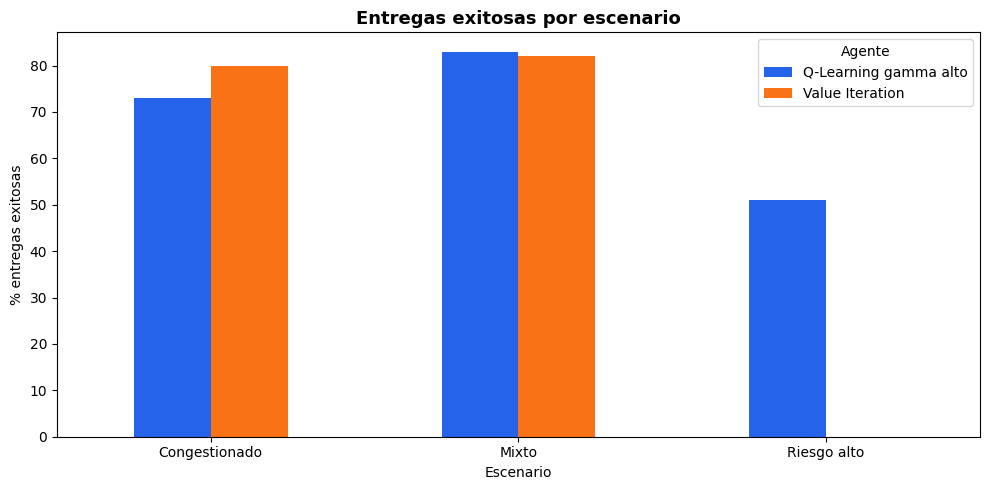

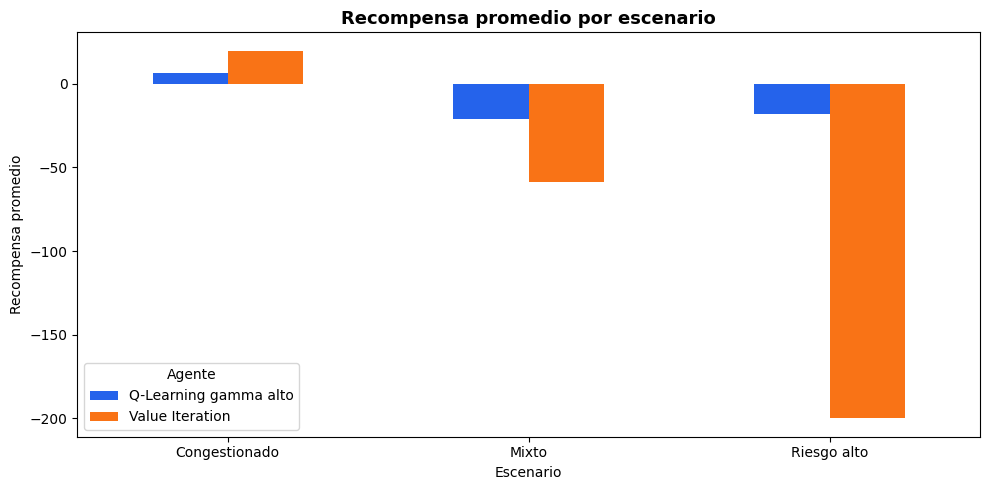

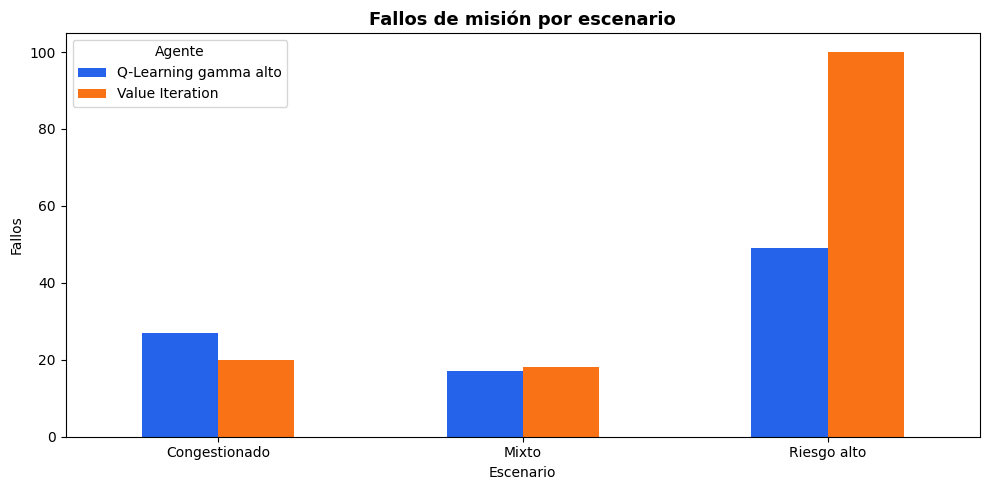

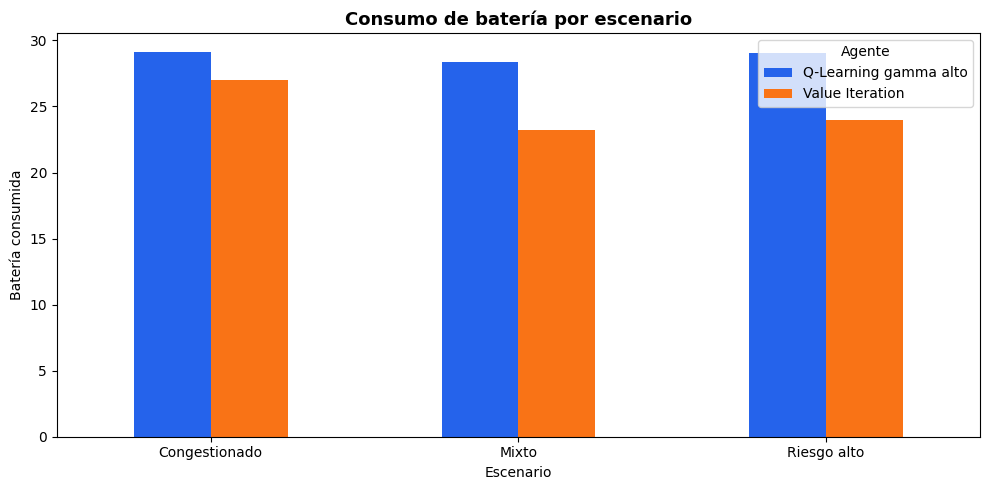

In [22]:
def plot_grouped_bars(df, metric, title, ylabel, filename):
    pivot = df.pivot(index="Escenario", columns="Agente", values=metric)

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 5),
        color=[agent_colors.get(col, "#6b7280") for col in pivot.columns]
    )

    plt.title(title, fontsize=13, fontweight="bold")
    plt.ylabel(ylabel)
    plt.xlabel("Escenario")
    plt.xticks(rotation=0)
    plt.legend(title="Agente")
    plt.tight_layout()
    plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)
    plt.show()


plot_grouped_bars(
    scenario_table,
    "% entregas exitosas",
    "Entregas exitosas por escenario",
    "% entregas exitosas",
    "escenarios_entregas_exitosas.png",
)

plot_grouped_bars(
    scenario_table,
    "Recompensa acumulada promedio",
    "Recompensa promedio por escenario",
    "Recompensa promedio",
    "escenarios_recompensa_promedio.png",
)

plot_grouped_bars(
    scenario_table,
    "Fallos de misión",
    "Fallos de misión por escenario",
    "Fallos",
    "escenarios_fallos_mision.png",
)

plot_grouped_bars(
    scenario_table,
    "Consumo promedio de batería",
    "Consumo de batería por escenario",
    "Batería consumida",
    "escenarios_consumo_bateria.png",
)

## 16. Ganador por métrica y escenario

Esta tabla resume qué agente tuvo mejor desempeño por métrica en cada escenario.

In [23]:
winner_rows = []

for scenario_name in scenario_table["Escenario"].unique():
    subset = scenario_table[scenario_table["Escenario"] == scenario_name].copy()

    metrics_rules = [
        ("Tiempo promedio de entrega", "Menor"),
        ("Consumo promedio de batería", "Menor"),
        ("% entregas exitosas", "Mayor"),
        ("Recompensa acumulada promedio", "Mayor"),
        ("Fallos de misión", "Menor"),
    ]

    for metric, criterion in metrics_rules:
        valid = subset.dropna(subset=[metric])
        if valid.empty:
            continue

        if criterion == "Mayor":
            winner = valid.loc[valid[metric].idxmax(), "Agente"]
        else:
            winner = valid.loc[valid[metric].idxmin(), "Agente"]

        winner_rows.append({
            "Escenario": scenario_name,
            "Métrica": metric,
            "Mejor resultado": criterion,
            "Ganador": winner,
        })

winner_table = pd.DataFrame(winner_rows)
winner_table.to_csv(
    tables_dir / "ganador_por_metrica_y_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

winner_table

,Escenario,Métrica,Mejor resultado,Ganador
0,Congestionado,Tiempo promedio de entrega,Menor,Value Iteration
1,Congestionado,Consumo promedio de batería,Menor,Value Iteration
2,Congestionado,% entregas exitosas,Mayor,Value Iteration
3,Congestionado,Recompensa acumulada promedio,Mayor,Value Iteration
4,Congestionado,Fallos de misión,Menor,Value Iteration
5,Riesgo alto,Tiempo promedio de entrega,Menor,Q-Learning gamma alto
6,Riesgo alto,Consumo promedio de batería,Menor,Value Iteration
7,Riesgo alto,% entregas exitosas,Mayor,Q-Learning gamma alto
8,Riesgo alto,Recompensa acumulada promedio,Mayor,Q-Learning gamma alto
9,Riesgo alto,Fallos de misión,Menor,Q-Learning gamma alto


## 17. Puntaje general normalizado

Este puntaje es solo una ayuda visual para resumir desempeño. No reemplaza las métricas reales. Se normalizan las métricas para que todas queden en escala 0 a 1:

- Mayor éxito es mejor.
- Mayor recompensa es mejor.
- Menor consumo de batería es mejor.
- Menor cantidad de fallos es mejor.

In [24]:
def minmax(series):
    if series.max() == series.min():
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

score_table = scenario_table.copy()

score_table["Éxito normalizado"] = score_table["% entregas exitosas"] / 100
score_table["Recompensa normalizada"] = minmax(score_table["Recompensa acumulada promedio"])
score_table["Batería normalizada"] = 1 - minmax(score_table["Consumo promedio de batería"])
score_table["Fallos normalizados"] = 1 - minmax(score_table["Fallos de misión"])

score_columns = [
    "Éxito normalizado",
    "Recompensa normalizada",
    "Batería normalizada",
    "Fallos normalizados",
]

score_table["Puntaje general"] = score_table[score_columns].mean(axis=1)
score_table["Puntaje general"] = score_table["Puntaje general"].round(3)

score_table.to_csv(
    tables_dir / "puntaje_general_por_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

score_table[["Escenario", "Agente", "Puntaje general"] + score_columns]

,Escenario,Agente,Puntaje general,Éxito normalizado,Recompensa normalizada,Batería normalizada,Fallos normalizados
0,Congestionado,Value Iteration,0.783,0.80,1.000000,0.366269,0.963855
1,Congestionado,Q-Learning gamma alto,0.637,0.73,0.939943,0.000000,0.879518
2,Riesgo alto,Value Iteration,0.218,0.00,0.000000,0.872232,0.000000
3,Riesgo alto,Q-Learning gamma alto,0.493,0.51,0.828746,0.017036,0.614458
4,Mixto,Value Iteration,0.863,0.82,0.642477,1.000000,0.987952
5,Mixto,Q-Learning gamma alto,0.695,0.83,0.815187,0.132879,1.000000


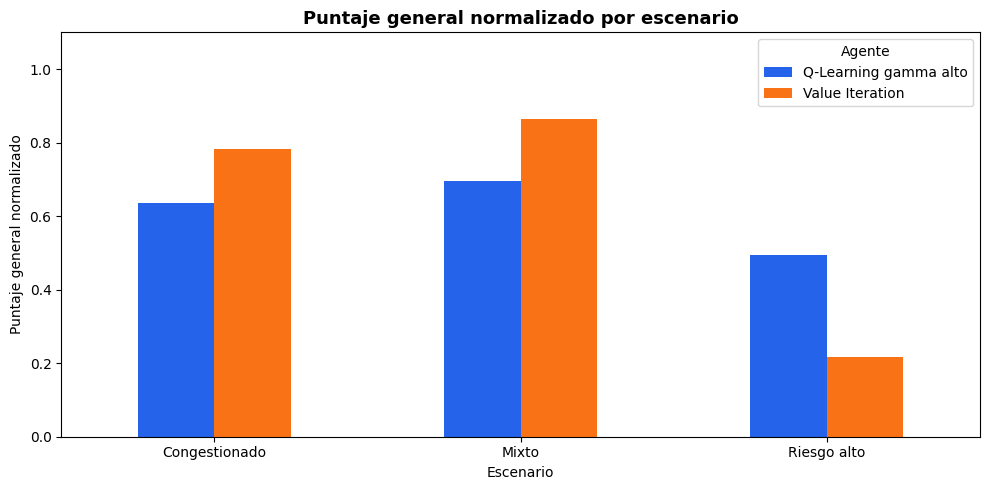

In [25]:
pivot_score = score_table.pivot(index="Escenario", columns="Agente", values="Puntaje general")

pivot_score.plot(
    kind="bar",
    figsize=(10, 5),
    color=[agent_colors.get(col, "#6b7280") for col in pivot_score.columns]
)

plt.title("Puntaje general normalizado por escenario", fontsize=13, fontweight="bold")
plt.ylabel("Puntaje general normalizado")
plt.xlabel("Escenario")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Agente")
plt.tight_layout()
plt.savefig(plots_dir / "puntaje_general_por_escenario.png", bbox_inches="tight", dpi=150)
plt.show()

## 18. Interpretación automática de resultados

Esta celda genera texto base que se puede usar en el informe o presentación.

In [26]:
print("Interpretación sugerida para el informe:")

base_vi = base_comparison[base_comparison["Agente"] == "Value Iteration"].iloc[0]
base_q  = base_comparison[base_comparison["Agente"] == best_q_name].iloc[0]

print(f"En el escenario base, Value Iteration obtuvo {base_vi['% entregas exitosas']:.1f}% de entregas exitosas, ")
print(f"mientras que {best_q_name} obtuvo {base_q['% entregas exitosas']:.1f}%.")

print("Value Iteration suele obtener mejores resultados porque utiliza un modelo conocido del entorno y calcula la política con la ecuación de Bellman.")
print("Q-Learning, en cambio, aprende mediante experiencia; por eso puede cometer más errores durante el entrenamiento y requiere más episodios para mejorar su política.")

best_q_success = q_experiment_table["% entregas exitosas"].max()
print(f"Las pruebas adicionales muestran que Q-Learning sí puede mejorar con ajuste de parámetros: la mejor configuración alcanzó {best_q_success:.1f}% de entregas exitosas en el escenario base.")

print("El análisis por escenarios (Congestionado, Riesgo alto, Mixto) permite observar la robustez de cada enfoque ante condiciones más difíciles del hospital.")
print("Si Value Iteration mantiene mejor desempeño en los escenarios adversos, se concluye que es más estable cuando el modelo del entorno está disponible.")
print("Si Q-Learning compite bien en algunos escenarios, se puede destacar que es útil cuando no se conocen las transiciones y el agente debe aprender directamente de la experiencia.")

Interpretación sugerida para el informe:
En el escenario base, Value Iteration obtuvo 90.0% de entregas exitosas, 
mientras que Q-Learning gamma alto obtuvo 77.0%.
Value Iteration suele obtener mejores resultados porque utiliza un modelo conocido del entorno y calcula la política con la ecuación de Bellman.
Q-Learning, en cambio, aprende mediante experiencia; por eso puede cometer más errores durante el entrenamiento y requiere más episodios para mejorar su política.
Las pruebas adicionales muestran que Q-Learning sí puede mejorar con ajuste de parámetros: la mejor configuración alcanzó 77.0% de entregas exitosas en el escenario base.
El análisis por escenarios (Congestionado, Riesgo alto, Mixto) permite observar la robustez de cada enfoque ante condiciones más difíciles del hospital.
Si Value Iteration mantiene mejor desempeño en los escenarios adversos, se concluye que es más estable cuando el modelo del entorno está disponible.
Si Q-Learning compite bien en algunos escenarios, se pu

## 19. Archivos generados

Al ejecutar este notebook se generan archivos en:

```text
results/
├── plots/
│   ├── mapa_base.png
│   ├── mapa_congestionado.png
│   ├── mapa_riesgo_alto.png
│   ├── mapa_mixto.png
│   ├── q_learning_mejor_curva_aprendizaje.png
│   ├── base_entregas_exitosas.png
│   ├── escenarios_entregas_exitosas.png
│   ├── escenarios_recompensa_promedio.png
│   ├── escenarios_fallos_mision.png
│   └── puntaje_general_por_escenario.png
│
└── tables/
    ├── metricas_base_vi_vs_mejor_q_learning.csv
    ├── comparacion_por_escenario.csv
    ├── ganador_por_metrica_y_escenario.csv
    └── puntaje_general_por_escenario.csv
```

Estos archivos pueden usarse para el informe, presentación y anexos.